<a href="https://colab.research.google.com/github/Samay-Kochhar/decision-analytics/blob/main/decision_analysis_bundesliga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#loading data and add season from the date
import numpy as np
import pandas as pd

#read csv
file_path = "Bundesliga_2019-2024.csv"
df = pd.read_csv(file_path)

#to convert date to season
df["Date"]   = pd.to_datetime(df["Date"], dayfirst=True)
df["Season"] = df["Date"].dt.year.where(df["Date"].dt.month >= 7,
                                        df["Date"].dt.year - 1)

#matchID
df = df.sort_values(["Season","Date","HomeTeam","AwayTeam"]).reset_index(drop=True)
df["MatchID"] = df.index + 1
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,MatchID
0,D1,2019-08-16,19:30,Bayern Munich,Hertha,2,2,D,1,2,...,2.03,1.90,1.99,1.93,2.04,1.93,1.98,1.91,2019,1
1,D1,2019-08-17,14:30,Dortmund,Augsburg,5,1,H,1,1,...,1.92,2.01,1.92,2.00,1.98,2.04,1.91,1.97,2019,2
2,D1,2019-08-17,14:30,Freiburg,Mainz,3,0,H,0,0,...,1.92,2.01,1.94,1.97,1.97,2.06,1.90,1.99,2019,3
3,D1,2019-08-17,14:30,Leverkusen,Paderborn,3,2,H,2,2,...,2.07,1.86,2.05,1.86,2.15,1.91,2.03,1.85,2019,4
4,D1,2019-08-17,17:30,M'gladbach,Schalke 04,0,0,D,0,0,...,1.99,1.94,1.98,1.94,2.02,2.13,1.93,1.95,2019,5


In [ ]:
# import pandas as pd

# # --- 1.  paths to your two files ---------------------------------
# csv_1 = "/content/SerieA_2014-2019.csv"
# csv_2 = "/content/SerieA_2019-2024.csv"

# # --- 2.  read them ------------------------------------------------
# df1 = pd.read_csv(csv_1)
# df2 = pd.read_csv(csv_2)

# # --- 3.  parse Date → datetime, derive Season ---------------------
# for df in (df1, df2):
#     df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
#     df["Season"] = df["Date"].dt.year.where(df["Date"].dt.month >= 7,
#                                             df["Date"].dt.year - 1)

# # --- 4.  append / concatenate ------------------------------------
# df = pd.concat([df1, df2], ignore_index=True)

# # --- 5.  sort & give each row a unique MatchID -------------------
# df = (df.sort_values(["Season", "Date", "HomeTeam", "AwayTeam"])
#         .reset_index(drop=True))
# df["MatchID"] = df.index + 1

# print("Combined rows:", len(df))
# print("Seasons:", sorted(df["Season"].unique()))
# df


In [ ]:
# ─── Stamp the true Match-day BEFORE any rows are removed ─────────
# def add_matchday(group):
#     # Serie A has 20 clubs → 10 matches per round
#     matches_per_round = 10
#     # keep each season in chronological order
#     group = group.sort_values("Date").reset_index(drop=True)
#     # integer-divide the running row index by matches_per_round
#     group["Matchday"] = group.index // matches_per_round + 1
#     return group

# # apply season-by-season
# df = df.groupby("Season", group_keys=False).apply(add_matchday)
# df

In [ ]:
#team names in each season

# for yr in sorted(df["Season"].unique()):
#     clubs = sorted(set(df.loc[df["Season"] == yr, "HomeTeam"]))
#     print(f"\nSeason {yr}/{yr+1}:")
#     print(", ".join(clubs))

In [ ]:
# list of promoted teams : Bundesliga
promoted_D1 = {
    2019: {"FC Koln", "Paderborn"},          # season 2019/20
    2020: {"Bielefeld", "Stuttgart"},        # 2020/21
    2021: {"Bochum", "Greuther Furth"},      # 2021/22
    2022: {"Schalke 04", "Werder Bremen"},   # 2022/23
    2023: {"Heidenheim", "Darmstadt"},       # 2023/24
}
# Serie A
# promoted_D1 = {
#     2014: {"Palermo", "Empoli"},          # season 2018/19
#     2015: {"Carpi", "Frosinone"},
#     2016: {"Cagliari", "Crotone"},
#     2017: {"Spal", "Verona"},
#     2018: {"Parma", "Empoli"},
#     2019: {"Brescia", "Lecce"},          # season 2019/20
#     2020: {"Benevento", "Crotone"},        # 2020/21
#     2021: {"Empoli", "Salernitana"},      # 2021/22
#     2022: {"Cremonese", "Lecce"},   # 2022/23
#     2023: {"Frosinone", "Genoa"},       # 2023/24
# }

In [ ]:
#details of the matches played between the promoted teams, in next step these rows will be removed.
promoted_D1 = {
    2019: {"FC Koln", "Paderborn"},          # season 2019/20
    2020: {"Bielefeld", "Stuttgart"},        # 2020/21
    2021: {"Bochum", "Greuther Furth"},      # 2021/22
    2022: {"Schalke 04", "Werder Bremen"},   # 2022/23
    2023: {"Heidenheim", "Darmstadt"},       # 2023/24
}

# select and in next step delete the rows when mathc is between two promoted teams
mask_promoted_pair = df.apply(
    lambda r: r["Div"] == "D1"
           and r["HomeTeam"] in promoted_D1.get(r["Season"], set())
           and r["AwayTeam"] in promoted_D1.get(r["Season"], set()),
    axis=1
)

# to see which matches will be removed so to check basically
promoted_vs_promoted = df.loc[mask_promoted_pair,
                              ["Date", "Season", "HomeTeam", "AwayTeam"] \
                              + [col for col in df.columns if col not in
                                 {"Date","Season","HomeTeam","AwayTeam"}]]

print(f"{len(promoted_vs_promoted)} promoted-vs-promoted fixtures:")
print(promoted_vs_promoted.to_string(index=False))

10 promoted-vs-promoted fixtures:
      Date  Season       HomeTeam       AwayTeam Div  Time  FTHG  FTAG FTR  HTHG  HTAG HTR  HS  AS  HST  AST  HF  AF  HC  AC  HY  AY  HR  AR  B365H  B365D  B365A  BWH  BWD  BWA  IWH  IWD  IWA  PSH  PSD  PSA  WHH  WHD  WHA  VCH  VCD  VCA  MaxH  MaxD  MaxA  AvgH  AvgD  AvgA  B365>2.5  B365<2.5  P>2.5  P<2.5  Max>2.5  Max<2.5  Avg>2.5  Avg<2.5   AHh  B365AHH  B365AHA  PAHH  PAHA  MaxAHH  MaxAHA  AvgAHH  AvgAHA  B365CH  B365CD  B365CA  BWCH  BWCD  BWCA  IWCH  IWCD  IWCA  PSCH  PSCD  PSCA  WHCH  WHCD  WHCA  VCCH  VCCD  VCCA  MaxCH  MaxCD  MaxCA  AvgCH  AvgCD  AvgCA  B365C>2.5  B365C<2.5  PC>2.5  PC<2.5  MaxC>2.5  MaxC<2.5  AvgC>2.5  AvgC<2.5  AHCh  B365CAHH  B365CAHA  PCAHH  PCAHA  MaxCAHH  MaxCAHA  AvgCAHH  AvgCAHA  MatchID
2019-10-20    2019        FC Koln      Paderborn  D1 14:30     3     0   H     1     0   H  16   9    6    1   6   7   6   9   0   0   0   0   1.65   4.50   4.33 1.67  4.2 4.60 1.75 4.00 4.30 1.69 4.42 4.65 1.65 4.33 4.60 1.65 4.40 4.20

In [ ]:
#after confirming we remove the matches between two promoted teams
df = df.loc[~mask_promoted_pair].reset_index(drop=True)

# 2.  Quick confirmation
print("Promoted-vs-promoted fixtures removed:", mask_promoted_pair.sum())
print("Remaining rows:", len(df))

Promoted-vs-promoted fixtures removed: 10
Remaining rows: 1520


In [ ]:
#to check if in the betting odds column all values are present and are numeric as in the research paper 4 values were missing

# --- 1. define the odds columns we require -----------------------------------
odds_cols = ["B365H", "B365D", "B365A"]

# --- 2. make a copy so the original df is untouched for inspection -----------
df_raw = df.copy()

# --- 3. coerce odds to numeric (non‑numeric → NaN) ---------------------------
df_raw[odds_cols] = df_raw[odds_cols].apply(pd.to_numeric, errors="coerce")

# --- 4. identify rows with any missing odds ----------------------------------
missing_mask = df_raw[odds_cols].isna().any(axis=1)
n_missing    = missing_mask.sum()

if n_missing == 0:
    print("✅  All matches have complete Bet365 odds.")
else:
    print(f"⚠️  {n_missing} matches missing at least one Bet365 odd:")
    # show a concise list of the first few problematic rows
    cols_to_show = ["Date", "HomeTeam", "AwayTeam"] + odds_cols
    print(df_raw.loc[missing_mask, cols_to_show].head().to_string(index=False))

# --- 5. drop those rows ------------------------------------------------------
df_clean = df_raw.loc[~missing_mask].reset_index(drop=True)
print(f"\nRemaining matches after drop: {len(df_clean)}")


✅  All matches have complete Bet365 odds.

Remaining matches after drop: 1520


In [ ]:
# #adding a new matchday column
df["seq"]      = df.groupby("Season").cumcount()       # 0…303
df["Matchday"] = df["seq"] // 9 + 1                   # 9 matches per round
df.drop(columns="seq", inplace=True)
df.tail(10)

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,MatchID,Matchday
1510,D1,2024-05-12,14:30,Darmstadt,Hoffenheim,0,6,A,0,5,...,1.78,2.10,1.81,2.12,1.95,1.98,1.87,2023,1521,33
1511,D1,2024-05-18,14:30,Dortmund,Darmstadt,4,0,H,2,0,...,2.00,1.87,2.02,1.88,2.11,1.85,2.01,2023,1522,33
1512,D1,2024-05-18,14:30,Ein Frankfurt,RB Leipzig,2,2,D,0,1,...,2.00,1.93,1.96,2.40,2.00,2.05,1.84,2023,1523,33
1513,D1,2024-05-18,14:30,Heidenheim,FC Koln,4,1,H,3,0,...,2.08,1.86,2.07,1.95,2.09,1.84,2.01,2023,1524,34
1514,D1,2024-05-18,14:30,Hoffenheim,Bayern Munich,4,2,H,1,2,...,1.90,2.01,1.90,2.04,1.94,1.95,1.90,2023,1525,34
1515,D1,2024-05-18,14:30,Leverkusen,Augsburg,2,1,H,2,0,...,1.95,1.95,1.93,2.03,1.97,1.97,1.88,2023,1526,34
1516,D1,2024-05-18,14:30,Stuttgart,M'gladbach,4,0,H,2,0,...,2.05,1.81,2.06,1.95,2.13,1.84,2.01,2023,1527,34
1517,D1,2024-05-18,14:30,Union Berlin,Freiburg,2,1,H,0,0,...,2.02,1.92,2.01,1.98,2.05,1.91,1.95,2023,1528,34
1518,D1,2024-05-18,14:30,Werder Bremen,Bochum,4,1,H,1,0,...,2.01,1.90,2.00,1.93,2.04,1.86,1.99,2023,1529,34
1519,D1,2024-05-18,14:30,Wolfsburg,Mainz,1,3,A,1,1,...,2.02,1.92,1.99,1.99,2.02,1.92,1.93,2023,1530,34


In [ ]:
#margin in the betting odds
df["Overround"] = (1/df["B365H"] + 1/df["B365D"] + 1/df["B365A"])
df["InvH"] = 1/df["B365H"]
df["InvA"] = 1/df["B365A"]
df["InvD"] = 1/df["B365D"]
df.tail()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,MaxCAHA,AvgCAHH,AvgCAHA,Season,MatchID,Matchday,Overround,InvH,InvA,InvD
1515,D1,2024-05-18,14:30,Leverkusen,Augsburg,2,1,H,2,0,...,1.97,1.97,1.88,2023,1526,34,1.047009,0.769231,0.111111,0.166667
1516,D1,2024-05-18,14:30,Stuttgart,M'gladbach,4,0,H,2,0,...,2.13,1.84,2.01,2023,1527,34,1.052841,0.775194,0.117647,0.160000
1517,D1,2024-05-18,14:30,Union Berlin,Freiburg,2,1,H,0,0,...,2.05,1.91,1.95,2023,1528,34,1.056022,0.476190,0.285714,0.294118
1518,D1,2024-05-18,14:30,Werder Bremen,Bochum,4,1,H,1,0,...,2.04,1.86,1.99,2023,1529,34,1.055089,0.420168,0.357143,0.277778
1519,D1,2024-05-18,14:30,Wolfsburg,Mainz,1,3,A,1,1,...,2.02,1.92,1.93,2023,1530,34,1.052760,0.312500,0.454545,0.285714


In [ ]:
#creating two rows one for homebet and other for awaybet
#one row to account for the bet on the home team and another one for the bet on the away team.

home = pd.DataFrame({
    "MatchID":  df["MatchID"],
    "Season":   df["Season"],
    "Matchday": df["Matchday"],
    "Team":     df["HomeTeam"],
    "Opponent": df["AwayTeam"],
    "IsHome":   1,
    "Odds":     df["B365H"],
    "Outcome":  (df["FTR"]=="H").astype(int),
    "BookProb": df["InvH"] / df["Overround"],
})

away = pd.DataFrame({
    "MatchID":  df["MatchID"],
    "Season":   df["Season"],
    "Matchday": df["Matchday"],
    "Team":     df["AwayTeam"],
    "Opponent": df["HomeTeam"],
    "IsHome":   0,
    "Odds":     df["B365A"],
    "Outcome":  (df["FTR"]=="A").astype(int),
    "BookProb": df["InvA"] / df["Overround"],
})

bets = pd.concat([home, away], ignore_index=True)
bets

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb
0,1,2019,1,Bayern Munich,Hertha,1,1.14,0,0.820681
1,2,2019,1,Dortmund,Augsburg,1,1.20,1,0.791304
2,3,2019,1,Freiburg,Mainz,1,2.25,1,0.424796
3,4,2019,1,Leverkusen,Paderborn,1,1.25,1,0.761905
4,5,2019,1,M'gladbach,Schalke 04,1,2.00,0,0.475113
...,...,...,...,...,...,...,...,...,...
3035,1526,2023,34,Augsburg,Leverkusen,0,9.00,0,0.106122
3036,1527,2023,34,M'gladbach,Stuttgart,0,8.50,0,0.111742
3037,1528,2023,34,Freiburg,Union Berlin,0,3.50,0,0.270557
3038,1529,2023,34,Bochum,Werder Bremen,0,2.80,0,0.338496


In [ ]:
# import pandas as pd

# # -- df already cleaned of promoted-pair fixtures -----------------------------
# # 1️⃣  sort and assign an integer counter within each season
# df = df.sort_values(["Season", "Date", "Time", "HomeTeam"]).reset_index(drop=True)
# df["seq_within_season"] = df.groupby("Season").cumcount()        # 0,1,2,…

# # 2️⃣  convert that counter to match-day (9 fixtures per round)
# df["Matchday"] = df["seq_within_season"] // 9 + 1
# df.drop(columns="seq_within_season", inplace=True)

# # 3️⃣  build the two-row “bets” dataframe as before ---------------------------
# long_home = pd.DataFrame({
#     "MatchID" : df.index + 1,
#     "Season"  : df["Season"],
#     "Matchday": df["Matchday"],
#     "Team"    : df["HomeTeam"],
#     "Opponent": df["AwayTeam"],
#     "IsHome"  : 1,
#     "Odds"    : df["B365H"],
#     "Outcome" : (df["FTR"] == "H").astype(int),
# })

# long_away = pd.DataFrame({
#     "MatchID" : df.index + 1,
#     "Season"  : df["Season"],
#     "Matchday": df["Matchday"],
#     "Team"    : df["AwayTeam"],
#     "Opponent": df["HomeTeam"],
#     "IsHome"  : 0,
#     "Odds"    : df["B365A"],
#     "Outcome" : (df["FTR"] == "A").astype(int),
# })

# bets = pd.concat([long_home, long_away], ignore_index=True)
# bets.head(20)


In [ ]:
# names of promoted teams
promoted_by_season = {
    2019: {"FC Koln", "Paderborn"},          # season 2019/20
    2020: {"Bielefeld", "Stuttgart"},        # 2020/21
    2021: {"Bochum", "Greuther Furth"},      # 2021/22
    2022: {"Schalke 04", "Werder Bremen"},   # 2022/23
    2023: {"Heidenheim", "Darmstadt"},       # 2023/24
}

#if match has a promoted team
bets["Promoted"] = bets.apply(
    lambda row: row["Team"] in promoted_by_season.get(row["Season"], set()),
    axis=1
).astype(int)

# 6‑C.  Interaction: promoted *and* playing at home
bets["Home_x_Prom"] = bets["IsHome"] * bets["Promoted"]

# 6‑D.  Interaction: promoted team and which match‑day it is
bets["Prom_x_MD"] = bets["Promoted"] * bets["Matchday"]
bets

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD
0,1,2019,1,Bayern Munich,Hertha,1,1.14,0,0.820681,0,0,0
1,2,2019,1,Dortmund,Augsburg,1,1.20,1,0.791304,0,0,0
2,3,2019,1,Freiburg,Mainz,1,2.25,1,0.424796,0,0,0
3,4,2019,1,Leverkusen,Paderborn,1,1.25,1,0.761905,0,0,0
4,5,2019,1,M'gladbach,Schalke 04,1,2.00,0,0.475113,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3035,1526,2023,34,Augsburg,Leverkusen,0,9.00,0,0.106122,0,0,0
3036,1527,2023,34,M'gladbach,Stuttgart,0,8.50,0,0.111742,0,0,0
3037,1528,2023,34,Freiburg,Union Berlin,0,3.50,0,0.270557,0,0,0
3038,1529,2023,34,Bochum,Werder Bremen,0,2.80,0,0.338496,0,0,0


In [ ]:
# bets is the DataFrame in “long” format (one row = one bet)

bets["Profit"] = bets.apply(
    lambda row: (row["Odds"] - 1) if row["Outcome"] == 1 else -1,
    axis=1
)
bets


,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD,Profit
0,1,2019,1,Bayern Munich,Hertha,1,1.14,0,0.820681,0,0,0,-1.00
1,2,2019,1,Dortmund,Augsburg,1,1.20,1,0.791304,0,0,0,0.20
2,3,2019,1,Freiburg,Mainz,1,2.25,1,0.424796,0,0,0,1.25
3,4,2019,1,Leverkusen,Paderborn,1,1.25,1,0.761905,0,0,0,0.25
4,5,2019,1,M'gladbach,Schalke 04,1,2.00,0,0.475113,0,0,0,-1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3035,1526,2023,34,Augsburg,Leverkusen,0,9.00,0,0.106122,0,0,0,-1.00
3036,1527,2023,34,M'gladbach,Stuttgart,0,8.50,0,0.111742,0,0,0,-1.00
3037,1528,2023,34,Freiburg,Union Berlin,0,3.50,0,0.270557,0,0,0,-1.00
3038,1529,2023,34,Bochum,Werder Bremen,0,2.80,0,0.338496,0,0,0,-1.00


In [ ]:
#28 matches when the promoted team won in away match
# profitable_promoted_bets = bets[(bets['Promoted'] == 1) & (bets['Profit'] > 0) & (bets.index> 1520)]
profitable_promoted_bets = bets[(bets['Promoted'] == 1) & (bets['Outcome'] == 1) & (bets['IsHome'] == 0) & (bets['Profit'] > 0)]
profitable_promoted_bets.sort_values('Profit', ascending=False)

,MatchID,Season,Matchday,Team,Opponent,IsHome,Odds,Outcome,BookProb,Promoted,Home_x_Prom,Prom_x_MD,Profit
2045,529,2020,25,Bielefeld,Leverkusen,0,9.00,1,0.105126,1,0,25,8.00
2408,895,2021,32,Bochum,Dortmund,0,7.50,1,0.125893,1,0,32,6.50
2452,939,2022,3,Werder Bremen,Dortmund,0,7.50,1,0.125893,1,0,3,6.50
2373,860,2021,28,Bochum,Hoffenheim,0,6.50,1,0.146317,1,0,28,5.50
1915,398,2020,11,Stuttgart,Dortmund,0,6.00,1,0.157895,1,0,11,5.00
1644,126,2019,14,Paderborn,Werder Bremen,0,5.75,1,0.165674,1,0,14,4.75
2997,1487,2023,30,Darmstadt,FC Koln,0,5.75,1,0.165457,1,0,30,4.75
2701,1190,2022,30,Schalke 04,Mainz,0,5.25,1,0.180075,1,0,30,4.25
2864,1354,2023,15,Heidenheim,Mainz,0,4.75,1,0.200994,1,0,15,3.75
2116,600,2020,33,Stuttgart,M'gladbach,0,4.75,1,0.199032,1,0,33,3.75


In [ ]:
# import numpy as np
# # previous bet by bet version
# # # promoted team playing away game
# # #previous ROI for each match was calculated and this was creating problem as for 1 matchday it wsas calculated 2 times and similarly for many matches this created problem.
# promoted_away = bets[(bets["Promoted"] == 1) & (bets["IsHome"] == 0)]
# promoted_away = promoted_away.sort_values(["Season", "Matchday"]).reset_index(drop=True)

# # 2️⃣  take the Profit column as a plain Series (already numeric)
# profits = promoted_away["Profit"]

# # 3️⃣  running ROI  →  cumulative profit divided by number of bets so far
# cumulative_profit = profits.cumsum()
# bet_count         = np.arange(1, len(profits) + 1)
# roi_series        = cumulative_profit / bet_count

# # 4️⃣  attach ROI back to a little table for inspection
# result = promoted_away[["Season", "Matchday"]].copy()
# result["ROI"] = roi_series.values          # index now matches 1‑to‑1


# result


In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # ------------------------------------------------------------------
# # 0.  make sure your bets table has a Profit column
# #     (+odds‑1 if bet wins, else ‑1) – create it if missing
# # ------------------------------------------------------------------
# if "Profit" not in bets.columns:
#     bets["Profit"] = np.where(bets["Outcome"] == 1, bets["Odds"] - 1, -1)

# # ------------------------------------------------------------------
# # 1.  helper – compute *average* ROI per match‑day across seasons
# # ------------------------------------------------------------------
# def avg_roi_per_matchday(subset):
#     # ROI within each SEASON first
#     curves = (
#         subset.sort_values(["Season", "Matchday"])
#               .groupby("Season", group_keys=False)
#               .apply(lambda s:
#                      s.assign(cum_profit=s["Profit"].cumsum(),
#                               bet_num   = range(1, len(s)+1),
#                               roi       = s["Profit"].cumsum()
#                                          / range(1, len(s)+1)))
#     )
#     # then average ROI of each match‑day across seasons
#     return curves.groupby("Matchday")["roi"].mean()

# # ------------------------------------------------------------------
# # 2.  build three series
# # ------------------------------------------------------------------
# prom_all  = bets[bets["Promoted"] == 1]
# prom_home = prom_all[prom_all["IsHome"] == 1]
# prom_away = prom_all[prom_all["IsHome"] == 0]

# roi_all  = avg_roi_per_matchday(prom_all)
# roi_home = avg_roi_per_matchday(prom_home)
# roi_away = avg_roi_per_matchday(prom_away)

# # ------------------------------------------------------------------
# # 3.  plot bar charts in the same style as the paper
# # ------------------------------------------------------------------
# fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

# # Figure 1 – all promoted
# axes[0].bar(roi_all.index, roi_all.values, color="grey")
# axes[0].set_title("Aggregated ROIs (recently promoted teams)")
# axes[0].set_ylabel("ROI")

# # Figure 2a – promoted at home
# axes[1].bar(roi_home.index, roi_home.values, color="grey")
# axes[1].set_title("(a) ROIs when betting on recently promoted teams\nplaying at home")
# axes[1].set_ylabel("ROI")

# # Figure 2b – promoted away
# axes[2].bar(roi_away.index, roi_away.values, color="grey")
# axes[2].set_title("(b) ROIs when betting on recently promoted teams\nplaying away")
# axes[2].set_xlabel("Match‑day (1‑34)")
# axes[2].set_ylabel("ROI")

# plt.tight_layout()
# plt.show()

In [ ]:
#here we calculate ROI for each matchday so for each matchday the avg was taken and cumulated till the end for each match
# 1️⃣  keep only promoted-away bets
promoted_away = bets[(bets["Promoted"] == 1) & (bets["IsHome"] == 0)]

# 2️⃣  total profit and number of bets on each match-day
day_totals = (promoted_away
              .groupby("Matchday")["Profit"]
              .agg(total_profit="sum", bets="count")
              .sort_index())

# 3️⃣  running cumulative totals up to day k
day_totals["cum_profit"] = day_totals["total_profit"].cumsum()
day_totals["cum_bets"]   = day_totals["bets"].cumsum()

# 4️⃣  cumulative ROI after day k
day_totals["ROI"] = day_totals["cum_profit"] / day_totals["cum_bets"]

# 5️⃣  result: exactly 34 rows, one per match-day
result = day_totals.reset_index()[["Matchday", "ROI"]]
result


,Matchday,ROI
0,1,-1.000000
1,2,-0.710000
2,3,-0.294737
3,4,-0.165000
4,5,-0.344828
5,6,-0.366667
6,7,-0.394737
7,8,-0.425000
8,9,-0.436170
9,10,-0.432353


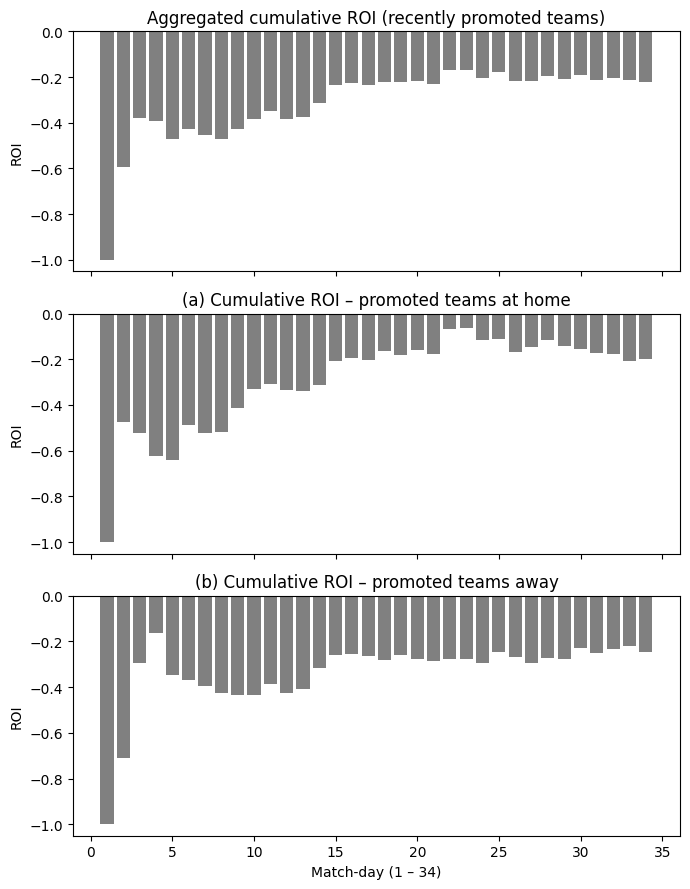

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 0. make sure Profit exists (+odds-1 if win, else -1)
if "Profit" not in bets.columns:
    bets["Profit"] = np.where(bets["Outcome"] == 1,
                              bets["Odds"] - 1,
                              -1)

# helper: cumulative ROI after each match-day (all seasons combined)
def cum_roi_by_day(subset):
    by_day = (subset
              .groupby("Matchday")["Profit"]
              .agg(total_profit="sum", bets="count")
              .sort_index())
    cum_profit = by_day["total_profit"].cumsum()
    cum_bets   = by_day["bets"].cumsum()
    return cum_profit / cum_bets            # ROI up to day k

# three betting strategies
prom_all  = bets[bets["Promoted"] == 1]
prom_home = prom_all[prom_all["IsHome"] == 1]
prom_away = prom_all[prom_all["IsHome"] == 0]

roi_all  = cum_roi_by_day(prom_all)
roi_home = cum_roi_by_day(prom_home)
roi_away = cum_roi_by_day(prom_away)

# bar-plot layout
fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

axes[0].bar(roi_all.index,  roi_all.values,  color="grey")
axes[0].set_title("Aggregated cumulative ROI (recently promoted teams)")
axes[0].set_ylabel("ROI")

axes[1].bar(roi_home.index, roi_home.values, color="grey")
axes[1].set_title("(a) Cumulative ROI – promoted teams at home")
axes[1].set_ylabel("ROI")

axes[2].bar(roi_away.index, roi_away.values, color="grey")
axes[2].set_title("(b) Cumulative ROI – promoted teams away")
axes[2].set_xlabel("Match-day (1 – 34)")
axes[2].set_ylabel("ROI")

plt.tight_layout()
plt.show()


In [ ]:
#this is the error one method we used bet by bet and in the other day by day ROI
#the paper uses ratio of totals = profitso far/no. of bets adn avg = ROi so far/no. of ROI
# prove counts differ across seasons/rounds
print(prom_away.groupby(["Season","Matchday"]).size().unstack(fill_value=0).head())

# show difference between the two ways on the same subset
roi_ratio_totals = cum_roi_by_day(prom_away)
roi_avg_of_ratios = avg_roi_per_matchday(prom_away)
diff = (roi_ratio_totals - roi_avg_of_ratios).abs().max()
print("Max |ratio_of_totals – average_of_ratios| =", diff)


Matchday  1   2   3   4   5   6   7   8   9   10  ...  25  26  27  28  29  30  \
Season                                            ...                           
2019       2   0   2   0   2   0   1   1   1   1  ...   1   1   0   2   0   2   
2020       1   1   1   1   1   1   1   1   1   1  ...   1   1   1   0   2   0   
2021       2   0   2   0   2   0   2   0   1   2  ...   0   1   0   2   0   2   
2022       2   0   2   0   2   0   2   0   2   0  ...   1   0   2   0   2   1   
2023       2   0   2   0   2   0   2   0   2   0  ...   2   0   2   1   1   1   

Matchday  31  32  33  34  
Season                    
2019       0   2   0   2  
2020       2   1   1   0  
2021       1   1   1   1  
2022       1   1   0   2  
2023       0   1   2   0  

[5 rows x 34 columns]
Max |ratio_of_totals – average_of_ratios| = 1.16


<ipython-input-12-715ca30fae19>:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda s:


In [ ]:
# #same thing just in termsn of line
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. helper: cumulative ROI for a single season & subset
# def roi_by_matchday(sub):
#     sub = sub.sort_values("Matchday")
#     profit = np.where(sub["Outcome"] == 1, sub["Odds"] - 1, -1)
#     cum_roi = profit.cumsum() / np.arange(1, len(profit)+1)
#     return pd.DataFrame({"Matchday": sub["Matchday"], "ROI": cum_roi})

# # 2. function to build the paper‑style average curve
# def average_roi(bets_subset):
#     # split into seasons, compute ROI curve per season,
#     # then average ROI values that share the same match‑day
#     curves = (bets_subset
#               .groupby("Season", group_keys=False)
#               .apply(roi_by_matchday))
#     return curves.groupby("Matchday")["ROI"].mean()

# # 3. prepare three subsets
# prom_all  = bets[bets["Promoted"] == 1]
# prom_home = prom_all[prom_all["IsHome"] == 1]
# prom_away = prom_all[prom_all["IsHome"] == 0]

# # 4. get the averaged curves
# curve_all  = average_roi(prom_all)
# curve_home = average_roi(prom_home)
# curve_away = average_roi(prom_away)

# # 5. plot – one clean line per category
# plt.figure(figsize=(8,5))
# plt.plot(curve_all.index,  curve_all.values,  label="All promoted",       lw=2)
# plt.plot(curve_home.index, curve_home.values, label="Promoted at home",   lw=1.7)
# plt.plot(curve_away.index, curve_away.values, label="Promoted away",      lw=1.7)

# plt.axhline(0, ls="--", lw=0.8, color="black")
# plt.xlabel("Match‑day (1 – 34)")
# plt.ylabel("Average ROI (euros won per euro staked)")
# plt.title("Bundesliga promoted‑team betting returns 2019‑24\n(average across seasons)")
# plt.legend();  plt.tight_layout();  plt.show()



In [ ]:
#check the graphs if they are correct ROi is calc rightly and for all years is averaged
#perform logistic regression
#check for 2014-2019 data
#take the note and think what should you work on next - so should we use this on many and confirm it is removed or what we should do? i check overround for promoted matches - dp promoted teams have higher overorund

In [ ]:
#cup competiton matches check implied probability, first round always with weak and strong teams, do on several teams.
#horizontal line for avg overround in the line chart graph
#check the graph as the cumulative dont add up
